# CRM → Billing configuration prediction — Sprints 1 to 3

**Case Study I** (Moodle section 8608). Final, self-contained notebook. All code is in this
notebook, and it reads **only the three files provided by the professor**: `train.csv`,
`test.csv` and `solution.csv`. The last of these is read only at the end, after the model is
frozen: to score it and for one ablation (Stage 1 without the corruption filter).
It is never used to train or choose anything.

**Task.** A 4-Play telecom subscription is provisioned in several systems that drift out of
sync. From a customer's **CRM** configuration (745 binary columns) predict the correct
**Billing (BIL)** configuration (731 binary columns).
**Metric: Exact Match Ratio (EMR)**: a row counts only if all 731 bits are right.

| Milestone (test EMR on `solution.csv`, computed after each model was frozen) | Test EMR |
|---|---|
| Sprint 2 champion | 95.04% |
| Sprint 3: suspected-corrupted training rows removed | 97.04% |
| Sprint 3: + regularisation re-tuned on clean data (+ Sprint 1 rules) | 97.27% |
| Stage 1 alone (professor's CSVs only, no Sprint 1 rules) | 97.21% (95% CI 97.11–97.31) — recomputed at the end |
| **This notebook's final model**: Stage 1 + long-tail specialists (Stage 2) | **97.51%** (95% CI 97.41–97.61) — recomputed at the end |
| Public benchmark (reported) | ~98% |

**Storyline.**
1. Sprint 1: the data and what makes it hard.
2. A validation design that mirrors the test set.
3. Sprint 2: four modelling paradigms, and why per-label trees win.
4. Sprint 3: an audit reveals ~7–8% of training rows that look corrupted by random injection; removing them is worth +2.5 test points (live ablation).
5. Final model, Stage 1: validation, uncertainty, baselines on the same footing, errors by segment.
6. Stage 2: specialists recover part of the long-tail billing items (macro F1 and EMR both up).
7. **Business use: flagging provisioning errors.**
8. SHAP explainability: the model learned the real product mapping.
9. Final fit, test score, and an ablation of the corruption filter.
10. Threats to validity and conclusions.

**Glossary.**

| Term | Meaning |
|---|---|
| EMR (exact match ratio) | share of customers whose 731 predicted billing bits are *all* correct |
| CRM configuration | the full 745-bit CRM row of a customer; identical rows = the same configuration |
| Consensus target | for a CRM configuration seen several times, its most frequent complete billing row (filters provisioning errors out of the labels) |
| Test-like row | a row whose categorical blocks are valid (exactly one status / type / business line, never the value `0`) — as in every test row |
| Rare pack | a CRM product present in fewer than 0.2% of training rows |
| Clean-like row | a test-like row with fewer than 3 rare packs; the validation population that behaves like the test set |
| Suspected-corrupted row | a training row that is not test-like or has 4+ rare packs; removed before training |
| Long-tail item | a billing item whose out-of-fold F1 inside the training data is below 0.5 (~330 items) |
| Stage 2 | one class-weighted LightGBM per long-tail item; it may only *add* an item, and only for customers with a rare pack |

Run time: about 25 minutes (three Stage-1 fits on 731 labels, two Stage-2 builds with 5 out-of-fold fits each).

## 0. Setup

In [1]:
import os
import re
import time
import warnings

os.environ.setdefault('OMP_NUM_THREADS', '6')
warnings.filterwarnings('ignore', message='X does not have valid feature names')

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from joblib import Parallel, delayed
from scipy import sparse
from scipy.stats import spearmanr
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.model_selection import GroupShuffleSplit, KFold

DATA = '../data'          # train.csv, test.csv, solution.csv (as provided by the professor)
OUT = f'{DATA}/derived'   # where the submission file is written
pd.set_option('display.max_colwidth', 90)
pd.set_option('display.width', 160)

# Chart style: one light surface, recessive axes, blue / orange series.
SURFACE, INK, INK2, GRID, AXIS = '#fcfcfb', '#0b0b0b', '#52514e', '#e1e0d9', '#c3c2b7'
BLUE, LIGHT_BLUE, ORANGE = '#2a78d6', '#9ec5f4', '#eb6834'
plt.rcParams.update({'font.family': 'sans-serif', 'font.size': 9, 'figure.facecolor': SURFACE})


def style(ax, grid='x'):
    ax.set_facecolor(SURFACE)
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)
    for s in ('left', 'bottom'):
        ax.spines[s].set_color(AXIS)
    ax.tick_params(colors=INK2, labelsize=8)
    ax.grid(axis=grid, color=GRID, linewidth=0.6)
    ax.set_axisbelow(True)

## 1. Load the data

Every CRM/BIL column is binary, so both files are read with an explicit `uint8` dtype map.
Pandas' default `int64` would use ~8× the memory on files of hundreds of MB.

In [2]:
t0 = time.time()
header = pd.read_csv(f'{DATA}/train.csv', nrows=0).columns.tolist()
crm_cols = [c for c in header if c.startswith('CRM')]
bil_cols = [c for c in header if c.startswith('BIL')]
dtypes = {c: 'uint8' for c in crm_cols + bil_cols} | {'MSISDN': str}

train = pd.read_csv(f'{DATA}/train.csv', dtype=dtypes)
test = pd.read_csv(f'{DATA}/test.csv', dtype={k: v for k, v in dtypes.items() if k in set(crm_cols) | {'MSISDN'}})
X = train[crm_cols].to_numpy(np.uint8)
Y_raw = train[bil_cols].to_numpy(np.uint8)
X_test = test[crm_cols].to_numpy(np.uint8)
msisdn_test = test['MSISDN'].to_numpy()
del train

print(f'train: {X.shape[0]:,} rows x {X.shape[1]} CRM + {Y_raw.shape[1]} BIL columns | '
      f'test: {X_test.shape[0]:,} rows | loaded in {time.time() - t0:.0f}s')
print(f'all values binary: {max(X.max(), Y_raw.max(), X_test.max()) <= 1}')

train: 187,442 rows x 745 CRM + 731 BIL columns | test: 97,100 rows | loaded in 9s
all values binary: True


---
# Sprint 1 — Pre-processing and exploratory analysis

The full Sprint 1 work is in `notebooks/sprint1_preprocessing_v3.ipynb`. The facts that
shaped Sprints 2 and 3 are recomputed here.

In [3]:
pack_crm = np.array([c.endswith('_PACK') for c in crm_cols])
pack_bil = np.array([c.endswith('_PACK') for c in bil_cols])
print(f'CRM: {pack_crm.sum()} pack flags + {(~pack_crm).sum()} categorical one-hot columns')
print(f'BIL: {pack_bil.sum()} pack flags + {(~pack_bil).sum()} categorical one-hot columns')
print(f'active columns per customer: CRM {X.sum(1).mean():.1f}, BIL {Y_raw.sum(1).mean():.1f}')

prev = Y_raw.mean(0)
tiers = pd.cut(prev, [-1e-9, 0.001, 0.01, 0.1, 0.5, 1.0],
               labels=['< 0.1%', '0.1–1%', '1–10%', '10–50%', '≥ 50%'])
print('\nBIL columns by prevalence (share of customers who have the item):')
display(pd.Series(tiers).value_counts().sort_index().rename('BIL columns').to_frame().T)

CRM: 730 pack flags + 15 categorical one-hot columns
BIL: 717 pack flags + 14 categorical one-hot columns


active columns per customer: CRM 15.3, BIL 14.7

BIL columns by prevalence (share of customers who have the item):


,< 0.1%,0.1–1%,1–10%,10–50%,≥ 50%
BIL columns,10,607,82,23,9


**Very sparse and imbalanced.** A customer has ~15 of 731 billing items, and over 600 billing
columns are active in less than 1% of rows. Getting *every* bit right is hard.

In [4]:
def row_keys(A):
    # Exact identity of each 0/1 row as bytes (np.packbits): no hashing, no collisions.
    return [r.tobytes() for r in np.packbits(np.asarray(A, dtype=np.uint8), axis=1)]


def factorize_rows(A):
    codes, uniq = pd.factorize(pd.Series(row_keys(A)), sort=False)
    return codes.astype(np.int64), len(uniq)


groups, n_crm_cfg = factorize_rows(X)
bil_codes, n_bil_cfg = factorize_rows(Y_raw)
pairs = pd.DataFrame({'crm': groups, 'bil': bil_codes})
n_bil_per_crm = pairs.groupby('crm')['bil'].nunique()
train_keys = set(row_keys(X))
seen = sum(k in train_keys for k in row_keys(X_test))

print(f'distinct CRM configurations: {n_crm_cfg:,} | distinct BIL configurations: {n_bil_cfg:,}')
print(f'CRM configurations with more than one BIL configuration (provisioning errors): '
      f'{(n_bil_per_crm > 1).sum():,} ({(n_bil_per_crm > 1).mean():.2%})')
print(f'test rows whose CRM configuration appears in train: {seen} of {len(X_test):,} ({seen / len(X_test):.4%})')

distinct CRM configurations: 67,434 | distinct BIL configurations: 67,201
CRM configurations with more than one BIL configuration (provisioning errors): 617 (0.91%)
test rows whose CRM configuration appears in train: 6 of 97,100 (0.0062%)


Three facts drove everything afterwards:
- **Noise.** Identical CRM configurations sometimes map to different billing. These are the
  provisioning errors the brief warns about.
- **Lookup does not transfer.** Essentially no test configuration appears in train, so the
  model must *generalise*. A random row split would let validation rows be answered by
  memorising duplicates, which is why validation is grouped by configuration (next section).
- **Sprint 1 built two candidate pipelines.** Section 10 relabels ambiguous groups and
  collapses correlated CRM columns. Section 11 adds a variance filter, χ² feature selection
  and 45 SVD components. Both were tested in Sprint 2.

In [5]:
# Recomputed here from train.csv (Sprint 1 Section 11 used the same truncated SVD on the CRM columns).
t0 = time.time()
svd = TruncatedSVD(n_components=80, algorithm='randomized', random_state=42).fit(sparse.csr_matrix(X, dtype=np.float32))
cum = np.cumsum(svd.explained_variance_ratio_)
k80 = int(np.argmax(cum >= 0.80)) + 1 if cum[-1] >= 0.80 else '> 80'
print(f'truncated SVD of the CRM columns: {k80} components needed for 80% of the variance '
      f'(first component alone: {svd.explained_variance_ratio_[0]:.1%}) -> no low-dimensional structure '
      f'[{time.time() - t0:.0f}s]')

truncated SVD of the CRM columns: 45 components needed for 80% of the variance (first component alone: 4.8%) -> no low-dimensional structure [2s]


---
# Validation design (used in Sprints 2 and 3)

- **Grouped split.** `GroupShuffleSplit` on the exact CRM configuration (20% validation,
  seed 42; every choice is confirmed on a second split, seed 7). No configuration is on both
  sides, as in the real test set.
- **Consensus targets.** Each validation row is scored against the most frequent *complete*
  BIL configuration of its CRM configuration, so the model is not rewarded for reproducing
  provisioning noise.
- **`solution.csv` is never used to learn or select.** It appears only in the last section,
  as a diagnostic of the frozen model.

In [6]:
def consensus_targets(crm_codes, Y):
    # Modal full BIL configuration per CRM configuration (ties: first seen).
    codes, _ = factorize_rows(Y)
    p = pd.DataFrame({'crm': crm_codes, 'bil': codes, 'pos': np.arange(len(Y))})
    cnt = p.groupby(['crm', 'bil'], sort=False).agg(n=('pos', 'size'), first=('pos', 'min')).reset_index()
    modal = cnt.sort_values(['crm', 'n', 'first'], ascending=[True, False, True]).drop_duplicates('crm')
    src = modal.set_index('crm')['first'].reindex(crm_codes).to_numpy()
    return Y[src], codes != codes[src]


def grouped_holdout(groups, seed=42):
    return next(GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=seed)
                .split(np.zeros(len(groups)), groups=groups))


Y, noisy = consensus_targets(groups, Y_raw)
tr, va = grouped_holdout(groups)
print(f'training rows that differ from their configuration consensus: {noisy.sum():,} ({noisy.mean():.2%})')
print(f'train fold {len(tr):,} rows | validation fold {len(va):,} rows | configurations on both sides: '
      f'{len(set(groups[tr]) & set(groups[va]))}')

training rows that differ from their configuration consensus: 1,315 (0.70%)
train fold 151,057 rows | validation fold 36,385 rows | configurations on both sides: 0


---
# Sprint 2 — Modelling

All four paradigms from the brief were compared on the same split. Those experiments took
hours to run (the project's `scripts/` and `docs/EXPERIMENT_LEADERBOARD.md`), so their results
are **reported here, not recomputed**. The final model is re-fitted live further below.

| Model (validation EMR, all rows, seed 42) | Validation EMR |
|---|---|
| Hamming k-NN (k=15): copy the billing of similar customers | 51.98% |
| Label powerset: choose among billing configurations seen in train | 23.09% |
| Binary relevance LightGBM, Section 10 pipeline as built | 50.58% |
| Binary relevance LightGBM, Section 11 pipeline (45 SVD components) as built | 12.80% |
| Binary relevance, raw CRM, unique configurations, weighted by multiplicity (bug) | 58.66% |
| Binary relevance, raw CRM, unique configurations, unweighted | 80.05% |
| Classifier chain (co-occurrence order) | 80.57% |
| **Binary relevance, regularised (Sprint 2 champion)** | **87.84%** |

| Feature set (same training rows and labels) | Validation EMR |
|---|---|
| raw 745 CRM columns | 80.05% |
| Section 10 features (correlated columns collapsed) | 74.31% |
| Section 11 features (+45 SVD components) | 47.42% |

What Sprint 2 established:
1. **Billing is close to additive per CRM pack.** A neighbour that differs by one CRM pack
   usually differs by one BIL bit. Neighbour copying fails; one model per BIL column learns
   the mapping.
2. **Label powerset is capped at ~23%**: unseen CRM configurations produce unseen BIL
   configurations.
3. **Neither Sprint 1 feature transformation helps.** On identical training rows, Section
   10's column collapsing costs ~6 points and Section 11's SVD components ~33. Raw columns
   are used from here on.
4. **How rows are weighted matters more than the model family.** Weighting unique
   configurations by multiplicity (up to 8,114×) made rare labels fire on ~5% of rows;
   removing the weights took the same model from 58.7% to 80.1%.
5. **Variance was the dominant error.** Stronger leaf regularisation gave the Sprint 2
   champion (87.84% validation, **95.04% test**).

---
# Sprint 3 — Optimisation: why was validation so much worse than test?

The Sprint 2 champion scored **87.8% on validation but 95.0% on test**. Following the
professor's hints (PCA, one-hot encoding, hidden pre-processing problems), each column family
was audited. Full audit trail: `docs/sprint3/SPRINT3_DIAGNOSTIC_LOG.md`.

## Finding 1 — impossible one-hot categories exist only in train

`BUSINESS_LINE`, `SUBSCRIBER_TYPE` and `SUBSCRIBER_STATUS` are one-hot blocks: exactly one
value per customer. A "test-like" row has exactly one value per block and never the value
literally called `0`.

In [7]:
def test_like_mask(A):
    blocks = {}
    for i, c in enumerate(crm_cols):
        m = re.match(r'^CRM_(.+?)_ORIG_(.+)$', c)
        if m:
            blocks.setdefault(m.group(1), []).append((i, m.group(2)))
    ok = np.ones(len(A), bool)
    for items in blocks.values():
        ok &= A[:, [i for i, _ in items]].sum(1) == 1
        zero = [i for i, v in items if v == '0']
        if zero:
            ok &= A[:, zero].sum(1) == 0
    return ok


test_like = test_like_mask(X)
print(f'test-like rows: train {test_like.mean():.2%} | test {test_like_mask(X_test).mean():.4%}')

status = np.array([c.startswith('CRM_SUBSCRIBER_STATUS_ORIG_') for c in crm_cols])
names = np.array([c.split('_ORIG_')[1] for c in np.array(crm_cols)[status]])
multi = X[:, status].sum(1) >= 2
combos = pd.Series(['+'.join(names[X[i, status] == 1]) for i in np.flatnonzero(multi)]).value_counts()
print(f'\n{multi.sum():,} training customers have 2+ statuses at once; most common combinations:')
display(combos.head(8).rename('customers').to_frame().T)

test-like rows: train 98.48% | test 99.9990%

1,901 training customers have 2+ statuses at once; most common combinations:


,Active+Barring,Active+Block_1_Way,Active+Block_2_Way,Active+Pre_Deactivated,Active+Deactive,0+Active,Active+Suspend,Active+Idle
customers,142,141,136,129,129,127,127,121


A customer cannot be `Active` and `Barring` at the same time. `Active` is paired with
*every* other status at almost the same rate, including very rare statuses and the
missing-value `0`, although those statuses differ in natural frequency by up to 100×. A real
status history would not be this uniform. These errors look **injected at random**.

## Finding 2 — bursts of random rare products in ~8% of training rows

A CRM pack is "rare" if it appears in fewer than 0.2% of training rows.

471 rare CRM packs | rows with >= 3 of them: train 8.00%, test 0.55%
in those rows the 471 rare packs are used almost equally often: coefficient of variation 0.12; rank correlation with their natural frequency in test 0.23
rare packs per row — not test-like rows: 6.43 CRM / 6.27 BIL; test-like rows: 0.50 / 0.50

rare CRM packs (rows) vs rare BIL items (columns) per training row — the counts move together:


rare BIL items,0,1,2,3,4,5,6
rare CRM packs,,,,,,,
0,159907,592,252,77,52,26,33
1,847,6020,485,235,161,102,137
2,143,329,1968,318,293,175,294
3,117,235,411,588,342,260,526
4,62,156,289,401,405,311,739
5,32,116,180,251,329,326,856
6,33,146,359,558,733,941,5294


a rare CRM pack's most associated rare BIL item appears with it in 29% of clean rows (median), but only 5% of rows with 3+ rare packs


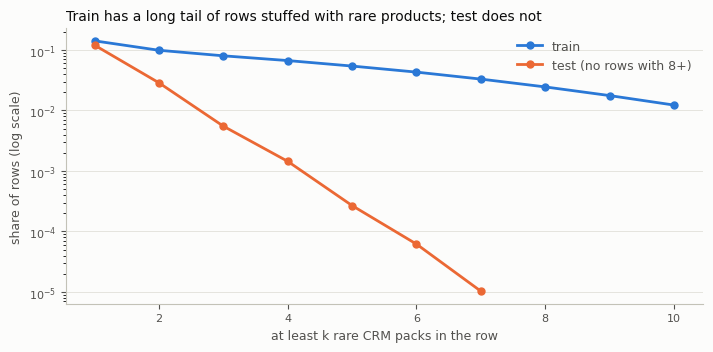

In [8]:
RARE_FREQ = 0.002
rare_crm = pack_crm & (X.mean(0) < RARE_FREQ)
rare_bil = pack_bil & (Y.mean(0) < RARE_FREQ)
rare_tr, rare_te = X[:, rare_crm].sum(1), X_test[:, rare_crm].sum(1)
rare_bil_tr = Y[:, rare_bil].sum(1)
print(f'{rare_crm.sum()} rare CRM packs | rows with >= 3 of them: train {np.mean(rare_tr >= 3):.2%}, '
      f'test {np.mean(rare_te >= 3):.2%}')

heavy = rare_tr >= 3
use = X[heavy][:, rare_crm].sum(0)
print(f'in those rows the {rare_crm.sum()} rare packs are used almost equally often: '
      f'coefficient of variation {use.std() / use.mean():.2f}; '
      f'rank correlation with their natural frequency in test {spearmanr(use, X_test[:, rare_crm].mean(0)).statistic:.2f}')
print(f'rare packs per row — not test-like rows: {rare_tr[~test_like].mean():.2f} CRM / '
      f'{rare_bil_tr[~test_like].mean():.2f} BIL; test-like rows: {rare_tr[test_like].mean():.2f} / '
      f'{rare_bil_tr[test_like].mean():.2f}')

print('\nrare CRM packs (rows) vs rare BIL items (columns) per training row — the counts move together:')
display(pd.crosstab(pd.Series(np.minimum(rare_tr, 6), name='rare CRM packs'),
                    pd.Series(np.minimum(rare_bil_tr, 6), name='rare BIL items')))


def partner_rate(mask):
    # For each rare CRM pack: how often its most associated rare BIL item appears with it.
    Xs, Ys = X[mask][:, rare_crm].astype(np.float32), Y[mask][:, rare_bil].astype(np.float32)
    n = Xs.sum(0)
    rate = (Xs.T @ Ys).max(1) / np.maximum(n, 1)
    return np.median(rate[n >= 5])


clean_rows = test_like & (rare_tr < 3)
print(f'a rare CRM pack\'s most associated rare BIL item appears with it in {partner_rate(clean_rows):.0%} of clean rows '
      f'(median), but only {partner_rate(rare_tr >= 3):.0%} of rows with 3+ rare packs')

ks = np.arange(1, 11)
share_te = np.array([np.mean(rare_te >= k) for k in ks])
fig, ax = plt.subplots(figsize=(7.2, 3.6))
ax.plot(ks, [np.mean(rare_tr >= k) for k in ks], color=BLUE, lw=2, marker='o', ms=5, label='train')
ax.plot(ks[share_te > 0], share_te[share_te > 0], color=ORANGE, lw=2, marker='o', ms=5,
        label=f'test (no rows with {ks[share_te > 0].max() + 1}+)')
ax.set_yscale('log')
style(ax, grid='y')
ax.set_xlabel('at least k rare CRM packs in the row', color=INK2)
ax.set_ylabel('share of rows (log scale)', color=INK2)
ax.set_title('Train has a long tail of rows stuffed with rare products; test does not', loc='left', color=INK, fontsize=10)
ax.legend(frameon=False, labelcolor=INK2)
plt.tight_layout()
plt.show()

Three signatures that point to **random injection** (strong circumstantial evidence, not
proof — rows are *suspected*, not known, to be corrupted):
1. **Train has a long tail that test does not.** About 8% of training rows carry 3 or more
   rare packs, against 0.55% of test rows.
2. **The rare packs are used almost uniformly at random.** Real customers do not pick
   products uniformly; random injection does.
3. **The two sides are corrupted together, but with unrelated identities.** The crosstab
   shows the number of rare CRM packs and of rare BIL items move together. Yet the link
   *between* them breaks down: in clean rows a rare CRM pack's most associated rare BIL item
   appears with it about 6× more often than in rows stuffed with rare packs. The row ends up
   with roughly the right number of products but the wrong identities, which is exactly the
   "~9 false positives + ~9 false negatives" signature of Sprint 2's worst rows.

The impossible categories of Finding 1 come with the same bursts of rare packs, so they look
like part of the same corruption. **Impact:** these rows make validation look ~8 points worse
than test, and they teach the model false links for rare products.

*How the understanding changed.* In Sprint 2 the multi-bit failures were read as model
failures (provisioning noise variants are only 1–2 bits). The Sprint 3 audit showed they
concentrate on these suspect rows, i.e. on the data rather than the model.

## The fix, and how it was chosen

- **Clean-like validation metric.** Score only rows that are test-like with fewer than 3
  rare packs (uses CRM inputs only). It tracks the test score: Sprint 2 champion 95.9% vs
  95.0% on test.
- **Drop suspected-corrupted rows from training.** The cut-off k (drop rows with k or more
  rare packs, or not test-like) was swept and checked on a second split. The model itself
  is unchanged. Results from the project's experiment scripts (clean-like validation EMR):

| k (drop rows with ≥ k rare packs) | Training rows dropped | Seed 42 | Seed 7 |
|---|---|---|---|
| no drop (Sprint 2 champion) | 0% | 95.93% | 95.06% |
| 2 | 9.8% | 95.45% | — |
| 3 | 8.1% | 96.41% | — |
| **4 (selected)** | **6.9%** | **96.57%** | **96.15%** |
| 5 | 5.8% | 96.50% | — |
| 6 | 4.9% | 96.62% | 95.80% |
| 8 | 3.4% | 96.30% | — |

Dropping too much (k=2) removes real customers; dropping too little (k=8) leaves corruption
in. k=4–6 form a plateau (differences of a few hundredths of a point on seed 42), and on the
second split k=4 is clearly best. **k=4 is selected.** A paired test (below) confirms the
filter itself: +0.81 / +1.25 points on the two splits.

## Re-tuning on the cleaned data, and what did not help

The Sprint 2 regularisation (`min_child_samples=20`) was chosen while the corruption was
still in the data. Re-tuned on clean data (clean-like validation EMR):

| Setting | Seed 42 | Seed 7 | Mean |
|---|---|---|---|
| `min_child_samples` 20 (after cleaning) | 96.57% | 96.15% | 96.36% |
| `min_child_samples` 10 | 96.78% | 96.11% | 96.45% |
| **`min_child_samples` 5 (selected)** | **96.81%** | **96.33%** | **96.57%** |
| `min_child_samples` 2 | 96.82% | 96.36% | 96.59% |
| `min_child_samples` 5, `reg_lambda` 5 | 96.61% | 96.25% | 96.43% |
| `min_child_samples` 5, `reg_lambda` 0 | 33.00% | 26.29% | collapse |
| + confident-learning cleaning | 96.59% | 96.01% | 96.30% |
| + repair corrupted rows instead of dropping | 96.60% | 96.03% | 96.31% |
| + more capacity (200 trees / 31 leaves) | 96.87% | 96.39% | 96.63% |
| + basket-size count features (a teammate's MCA lead) | 96.79% | 96.41% | 96.60% |

- **Smaller leaves help once the data is clean.** `min_child_samples=5` beats 20 on both
  splits (paired test below). 2 ties with 5 (paired difference not significant), so the more
  regularised 5 is kept.
- **L2 regularisation is essential.** With `reg_lambda=0` one rare billing item fires on 27%
  of rows.
- **Tested and rejected** (each on both splits): cleaning by out-of-fold disagreement (worse:
  it removes genuine rare products too), repairing corrupted rows (worse: stripping rare packs
  also strips real ones), more capacity (not significant in a paired test, double the time),
  and basket-size count features (inconsistent across splits).
- **A lower threshold for rare billing items is real but tiny:** positive on both splits and
  in all 5 cross-validation folds, but worth +0.03 points (about ten customers per fold). It is
  below the ~0.1-point bar we set *before* testing, so it was not adopted (see the paired
  tests below).
- **The 42 Sprint 1 "additive" rules are dropped from the final model.** They overwrote 42
  BIL columns with an OR of CRM triggers, but on the final model they add only +0.02 / +0.03
  (real but about six customers), and they were mined from all of `train.csv`, including later validation
  rows. Without them the model is simpler, leak-free, and needs nothing but the professor's
  CSVs.

---
# Final model, Stage 1 — re-fitted live

Per-label LightGBM on the raw 745 CRM columns:
- trained on unique CRM configurations with consensus labels, after dropping
  suspected-corrupted rows (not test-like, or 4+ rare packs);
- 100 trees, 15 leaves, `min_child_samples=5`, `reg_lambda=1`, threshold 0.5.

Fitted here on the seed-42 training fold, to reproduce the validation score and to explain it.
Stage 2 (specialists for the long-tail billing items) is added after the error analysis below.

In [9]:
PARAMS = dict(n_estimators=100, num_leaves=15, learning_rate=0.1, min_child_samples=5,
              reg_lambda=1.0, verbose=-1)


def fit_one(Xf, y):
    if y.min() == y.max():
        return float(y[0])
    return lgb.LGBMClassifier(n_jobs=2, **PARAMS).fit(Xf, y)


def fit_models(Xu, Yu):
    Xf = Xu.astype(np.float32)
    return Parallel(n_jobs=8, backend='threading')(delayed(fit_one)(Xf, Yu[:, j]) for j in range(Yu.shape[1]))


def predict_proba(models, A):
    Af = A.astype(np.float32)
    one = lambda m: np.full(len(Af), m, np.float32) if isinstance(m, float) else m.predict_proba(Af)[:, 1]
    return np.column_stack(Parallel(n_jobs=8, backend='threading')(delayed(one)(m) for m in models))


def unique_configs(A, B):
    codes, _ = factorize_rows(A)
    _, first = np.unique(codes, return_index=True)
    return A[first], B[first]


def predict(models, A):
    P = predict_proba(models, A)
    return P, (P >= 0.5).astype(np.uint8)


keep = tr[test_like[tr] & (rare_tr[tr] < 4)]
Xu, Yu = unique_configs(X[keep], Y[keep])
t0 = time.time()
models = fit_models(Xu, Yu)
P_val, pred_val = predict(models, X[va])
print(f'dropped {len(tr) - len(keep):,} suspected-corrupted training rows; '
      f'fitted 731 models on {len(Xu):,} unique configurations in {time.time() - t0:.0f}s')

dropped 10,476 suspected-corrupted training rows; fitted 731 models on 43,552 unique configurations in 96s


In [10]:
Yv = Y[va]
clean_like = test_like & (rare_tr < 3)
for name, m in [('all validation rows', np.ones(len(va), bool)), ('test-like rows', test_like[va]),
                ('clean-like rows (primary)', clean_like[va])]:
    emr = (pred_val[m] == Yv[m]).all(1).mean()
    print(f'{name:28s} {m.sum():6,} rows   EMR {emr:.2%}')

cl = clean_like[va]
yt, yp = Yv[cl], pred_val[cl]
active = yt.sum(0) > 0
report = pd.Series({
    'EMR': (yt == yp).all(1).mean(),
    'bit accuracy': (yt == yp).mean(),
    'F1 micro': f1_score(yt, yp, average='micro'),
    'F1 macro (columns with positives)': f1_score(yt[:, active], yp[:, active], average='macro', zero_division=0),
    'precision micro': precision_score(yt, yp, average='micro'),
    'recall micro': recall_score(yt, yp, average='micro'),
})
display(report.to_frame('clean-like validation').style.format('{:.4f}'))
cm = pd.DataFrame([[int(((yt == 1) & (yp == 1)).sum()), int(((yt == 1) & (yp == 0)).sum())],
                   [int(((yt == 0) & (yp == 1)).sum()), int(((yt == 0) & (yp == 0)).sum())]],
                  index=['actual 1', 'actual 0'], columns=['predicted 1', 'predicted 0'])
display(cm.style.format('{:,}'))
err = (yt != yp).sum(1)
r = rare_tr[va][cl]
print(f'EMR on clean-like rows with no rare pack: {np.mean(err[r == 0] == 0):.2%} | '
      f'with 1–2 rare packs ({np.mean(r > 0):.1%} of rows): {np.mean(err[r > 0] == 0):.2%}')

all validation rows          36,385 rows   EMR 88.64%
test-like rows               35,818 rows   EMR 90.04%
clean-like rows (primary)    33,261 rows   EMR 96.79%


,clean-like validation
EMR,0.9679
bit accuracy,0.9998
F1 micro,0.9959
F1 macro (columns with positives),0.5348
precision micro,0.9989
recall micro,0.9929


,predicted 1,predicted 0
actual 1,"474,408","3,378"
actual 0,525,"23,835,480"


EMR on clean-like rows with no rare pack: 99.17% | with 1–2 rare packs (7.1% of rows): 65.50%


- This is the Sprint 3 champion without the Sprint 1 rules (clean-like 96.79% vs 96.81%
  with them: a real but tiny difference of about six customers).
- Errors are mostly **missed** billing items: false negatives far outnumber false positives.
- Almost all remaining errors sit in the few rows with 1–2 rare products. Rows without one
  are ~99% exact.

### Why EMR is harsh, and how errors are distributed

With 731 bits per customer, even a tiny bit error rate would sink EMR if errors were spread
evenly. They are not.

In [11]:
bit_err = (yt != yp).mean()
print(f'bit error rate {bit_err:.2e} -> {bit_err * 731:.3f} wrong bits per customer on average')
print(f'EMR if errors were independent across bits: (1 - e)^731 = {(1 - bit_err) ** 731:.2%} | actual EMR {np.mean(err == 0):.2%}')
print(f'{np.mean(err >= 2):.2%} of customers carry {err[err >= 2].sum() / err.sum():.0%} of all wrong bits')

bit error rate 1.61e-04 -> 0.117 wrong bits per customer on average
EMR if errors were independent across bits: (1 - e)^731 = 88.93% | actual EMR 96.79%
2.15% of customers carry 91% of all wrong bits


Errors cluster in a small set of customers (the ones with rare products), so EMR is much
higher than independent errors would allow. This is why exact-match work is about *which
customers* fail, not about per-bit accuracy.

### Uncertainty

A configuration's rows share both the prediction and the consensus target, so they are not
independent observations. The standard error is therefore computed by resampling whole
**configurations** (bootstrap), not rows.

In [12]:
def config_bootstrap(groups_, values, b=2000, seed=0):
    codes, _ = pd.factorize(groups_)
    s, n = np.bincount(codes, weights=values), np.bincount(codes)
    idx = np.random.default_rng(seed).integers(0, len(s), size=(b, len(s)))
    boot = s[idx].sum(1) / n[idx].sum(1)
    return s.sum() / n.sum(), boot.std(), np.percentile(boot, [2.5, 97.5])


ok_row = (err == 0).astype(float)
m, se, (lo, hi) = config_bootstrap(groups[va][cl], ok_row)
print(f'clean-like validation EMR {m:.2%} | configuration-level SE {se * 100:.2f} pt '
      f'(a naive row-level SE would say {np.sqrt(m * (1 - m) / len(ok_row)) * 100:.2f}) | 95% CI [{lo:.2%}, {hi:.2%}]')

clean-like validation EMR 96.79% | configuration-level SE 0.38 pt (a naive row-level SE would say 0.10) | 95% CI [95.99%, 97.48%]

A single split's interval is wide (about ±0.7 points) because a few very frequent configurations
weigh heavily. Two consequences:
- **Model decisions are judged with paired tests** (both models scored on the same rows,
  resampling configurations), which cancel that shared noise.
- **The test set is the better yardstick for the final number:** every test row is its own
  configuration, so its confidence interval is narrow (computed at the end).

**Validation ranks choices; the test set measures them.** The two do not move one-for-one:
- The corruption filter is worth +0.8 / +1.25 points on validation but +2.0 to +2.5 on test.
- Validation customers are *closer* to a training customer than test customers are (a
  neighbour one product away for 70% vs 53%), which makes validation easier. But validation
  also keeps more unusual customers, which makes it harder.
- These biases partly cancel. That is why clean-like validation lands near the test score,
  and why we use validation to *compare* models (with paired tests on two splits and 5-fold
  cross-validation) rather than to predict the test number.

Results from the project's experiment scripts (`scripts/sprint3/review_checks.py`,
`exp12_review_models.py`), clean-like validation:

**Baselines on the same footing**

| Model | Seed 42 | Seed 7 |
|---|---|---|
| Hamming k-NN (k=15), copy similar customers' billing | 56.81% | 49.64% |
| Rules floor: bill an item if a CRM product implies it ≥ 90% of the time | 67.94% | 74.15% |
| Logistic regression, one per billing item, untuned (C = 1) | 95.97% | 94.61% |
| Logistic regression, tuned (best of C = 0.1, 1, 10, 100 → C = 10) | 96.56% | 96.15% |
| **LightGBM, one per billing item (final)** | **96.79%** | **96.30%** |

A *linear* model, once tuned, gets within **0.15–0.23 points** of LightGBM. That strongly
supports the finding that billing is close to additive per CRM product. LightGBM is still
better on both splits (paired test: +0.23 [+0.14, +0.34] on seed 42; +0.16 [−0.04, +0.33] on
seed 7, borderline), about 50–80 customers per validation fold, mostly on rare-product
interactions. A simpler linear model would be a reasonable alternative if interpretability
mattered more than the last few tenths of a point.

**Paired tests for the key decisions** (difference B − A in points, 95% configuration
bootstrap CI; ✓ = real on both splits)

| Decision (B vs A) | Seed 42 | Seed 7 | Verdict |
|---|---|---|---|
| Drop suspected-corrupted rows vs keep (k=4) | +0.81 [+0.44, +1.19] | +1.25 [+0.91, +1.74] | ✓ adopted |
| `min_child_samples` 5 vs 20 | +0.27 [+0.08, +0.62] | +0.20 [+0.08, +0.35] | ✓ adopted |
| Sprint 1 additive rules on vs off | +0.02 [+0.00, +0.04] | +0.02 [+0.00, +0.05] | real but ~6 customers; dropped (leak, needs a derived file) |
| Lower threshold (0.45) for rare billing items | +0.07 [+0.02, +0.16] | +0.10 [+0.03, +0.23] | real (positive on both splits and in all 5 folds) but tiny: +0.03 in 5-fold (~10 customers per fold) → not adopted, below the ~0.1-point bar set before testing |
| More capacity (200 trees / 31 leaves) | +0.04 [−0.04, +0.15] | +0.05 [−0.12, +0.23] | not significant |
| `min_child_samples` 2 vs 5 | −0.00 [−0.05, +0.04] | +0.03 [−0.03, +0.08] | not significant |
| Basket-size count feature | −0.02 [−0.08, +0.03] | +0.09 [−0.00, +0.23] | inconsistent |
| LightGBM vs tuned logistic regression (C = 10) | +0.23 [+0.14, +0.34] | +0.16 [−0.04, +0.33] | LightGBM kept: better on both, borderline on seed 7 |

**5-fold cross-validation of the final model** (GroupKFold by configuration): clean-like EMR
**96.83% ± 0.20** (standard deviation over folds; folds 96.64–97.12); all rows 89.07% ± 0.21.

### Errors by customer segment

In [13]:
crm_arr = np.array(crm_cols)
Xcl = X[va][cl]
seg_rows = []


def segment(name, labels):
    for lab in pd.unique(labels):
        mm = labels == lab
        seg_rows.append({'segment': name, 'value': lab, 'customers': int(mm.sum()), 'EMR': np.mean(err[mm] == 0),
                         'share of wrong customers': (err[mm] > 0).sum() / max((err > 0).sum(), 1)})


for g in ('SUBSCRIBER_STATUS', 'SUBSCRIBER_TYPE'):
    cols = [i for i, c in enumerate(crm_cols) if c.startswith(f'CRM_{g}_ORIG_')]
    segment(g.lower(), np.array([c.split('_ORIG_')[1] for c in crm_arr[cols]])[Xcl[:, cols].argmax(1)])
segment('CRM products per customer', pd.cut(Xcl[:, pack_crm].sum(1), [0, 10, 15, 20, 1000],
                                             labels=['<= 10', '11-15', '16-20', '21+']).astype(str))
segment('rare CRM products', np.where(rare_tr[va][cl] > 0, '1-2', '0'))
seg = pd.DataFrame(seg_rows).sort_values(['segment', 'customers'], ascending=[True, False]).set_index(['segment', 'value'])
display(seg.style.format({'EMR': '{:.2%}', 'share of wrong customers': '{:.1%}', 'customers': '{:,}'}))

The segment that matters is **product mix, not status or contract type**: customers with
1–2 rare products (7% of rows) hold three quarters of the errors, and EMR falls with basket
size (16+ products). Status and type barely move EMR.

### What the model cannot vouch for

In [14]:
tp_c = ((yt == 1) & (yp == 1)).sum(0)
fp_c = ((yt == 0) & (yp == 1)).sum(0)
fn_c = ((yt == 1) & (yp == 0)).sum(0)
f1_c = np.where(tp_c + fp_c + fn_c > 0, 2 * tp_c / np.maximum(2 * tp_c + fp_c + fn_c, 1), np.nan)
weak = f1_c < 0.5
has_weak = yt[:, weak].any(1)
print(f'billing items with validation F1 < 0.5: {np.nansum(weak)} of 731 columns, but only '
      f'{yt[:, weak].sum() / yt.sum():.2%} of all billed items')
print(f'customers billed for at least one such item: {has_weak.mean():.2%} | their EMR {np.mean(err[has_weak] == 0):.1%} '
      f'vs {np.mean(err[~has_weak] == 0):.2%} for everyone else')

billing items with validation F1 < 0.5: 314 of 731 columns, but only 0.34% of all billed items
customers billed for at least one such item: 2.38% | their EMR 5.8% vs 99.01% for everyone else


Macro F1 is low (~0.5) because it weights every billing item equally, and hundreds of items
are so rare that they are hard to learn. In business terms the impact is small: those items
are a fraction of a percent of what is billed, and about 2% of customers. For the other ~98%
the model is right ~99% of the time.

---
# Business use: flagging provisioning errors

The brief's goal is to **catch provisioning errors**. The model predicts the billing a
customer *should* have from their CRM configuration; comparing it with what the billing
system *actually* contains gives a ranked review queue.

**How it is evaluated.** On the validation fold we know some real provisioning errors:
customers whose CRM configuration appears several times and whose actual billing differs
from that configuration's consensus. Errors in configurations seen only once cannot be
confirmed, so the precision below is a **lower bound**.

---
# Stage 2 — specialists for the long-tail billing items

Macro F1 is low because about 330 billing items are almost never predicted. The project
investigated whether they can be recovered (diagnostic log, Steps 12–13; scripts
`exp13_macro_f1.py`, `exp14_longtail.py`, `exp15_kfold_longtail.py`). The diagnosis, from the
training fold only (seed 42):

| Group of long-tail items | Items | Validation positives | Mean validation F1 (Stage 1) |
|---|---|---|---|
| One CRM product bills it ≥ 50% of the time | 14 | 141 | 0.41 |
| A combination of 2–3 CRM products bills it ≥ 50% of the time | 105 | 711 | 0.25 |
| A common billing item implies it | 0 | — | — |
| Likely residue of the random injection (≥ 80% of positives next to a rare product, no signal) | 212 | 1,008 | 0.01 |

- The CRM patterns of the first two groups **transfer**: on validation they bill the item
  correctly 92–93% of the time. Stage 1 under-uses them because each item has only 20–50
  training configurations.
- Over 90% of the long tail's positives sit on customers with at least one rare CRM product.
- The long tail does not co-occur with common billing items (only 2% share a co-occurrence
  community with one), so other billing items carry no extra signal.

What was tried (both splits, paired tests against Stage 1; full table in the log):

| Approach | Result | Verdict |
|---|---|---|
| Per-item thresholds tuned on training OOF | macro F1 +0.01 but EMR −0.1 to −0.9 pt; the EMR-safe version gains only +0.001–0.002 | rejected |
| Specialists fed with all Stage-1 probabilities (cascade) or co-occurrence-community activations | they latch onto stacked probabilities; EMR −0.4 to −26 pt | rejected |
| Specialists + probabilities of related common items (targeted classifier chain) | weaker than CRM alone; EMR not significant on seed 7 | rejected |
| Specialists + mined CRM-pattern indicators | ties with CRM alone (paired test) | rejected (simpler wins) |
| Deterministic CRM-pattern override (training precision ≥ 0.9) | 3–4 customers | rejected (negligible) |
| **Specialists on CRM with class weights, add-only, only for customers with a rare CRM product** | **macro F1 +0.014 / +0.015, EMR +0.12 / +0.19 pt, both significant; positive in all 5 folds** | **adopted** |

**Design of Stage 2.**
1. *Long-tail items* = items whose out-of-fold F1 inside the training data is below 0.5
   (5 folds over unique configurations, weighted by rows). No validation or test labels.
2. *Specialists* = one LightGBM per long-tail item, Stage-1 settings, positives up-weighted
   (`scale_pos_weight` = √(negatives / positives), clipped to 1–10).
3. *Add-only merge*: a specialist can switch an item **on** where Stage 1 said 0 (p ≥ 0.5),
   only for customers with at least one rare CRM product. It never removes a Stage-1 item and
   never touches other items.

The rare-product gate was added after seeing which customers broke on seed 42, so seed 7 and
the 5-fold check below are the honest evidence. Fitted live on the seed-42 training fold:

In [15]:
def config_weights(A):
    # Rows per unique configuration, in the order returned by unique_configs.
    codes, _ = factorize_rows(A)
    _, first = np.unique(codes, return_index=True)
    return np.bincount(codes)[codes[first]].astype(np.float32)


def oof_proba(Xu_, Yu_, n_splits=5):
    # Out-of-fold Stage-1 probabilities on the training configurations (each fold = whole configurations).
    oof = np.zeros(Yu_.shape, np.float32)
    for a, b in KFold(n_splits, shuffle=True, random_state=0).split(Xu_):
        oof[b] = predict_proba(fit_models(Xu_[a], Yu_[a]), Xu_[b])
    return oof


def long_tail_labels(Yu_, oof, w):
    # Items whose row-weighted out-of-fold F1 at 0.5 is below 0.5.
    Yb, Pb = Yu_.astype(bool), oof >= 0.5
    tp, fp, fn = w @ (Yb & Pb), w @ (~Yb & Pb), w @ (Yb & ~Pb)
    f1 = np.where(tp + fp + fn > 0, 2 * tp / np.maximum(2 * tp + fp + fn, 1e-9), 1.0)
    return np.flatnonzero((Yu_.sum(0) > 0) & (f1 < 0.5))


def fit_specialists(Xu_, Yu_, labels):
    Xf = Xu_.astype(np.float32)

    def one(j):
        y = Yu_[:, j]
        spw = float(np.clip(np.sqrt((len(y) - y.sum()) / max(y.sum(), 1)), 1, 10))
        return lgb.LGBMClassifier(n_jobs=2, scale_pos_weight=spw, **PARAMS).fit(Xf, y)
    return Parallel(n_jobs=8, backend='threading')(delayed(one)(j) for j in labels)


def two_stage(pred1, specialists, labels, A):
    P2 = predict_proba(specialists, A)
    gate = (A[:, rare_crm].sum(1) > 0)[:, None]           # customers with >= 1 rare CRM product
    out = pred1.copy()
    sub_ = out[:, labels]
    out[:, labels] = np.where((sub_ == 0) & (P2 >= 0.5) & gate, 1, sub_)   # add-only
    return out


t0 = time.time()
lt_val = long_tail_labels(Yu, oof_proba(Xu, Yu), config_weights(X[keep]))
spec_val = fit_specialists(Xu, Yu, lt_val)
pred_val2 = two_stage(pred_val, spec_val, lt_val, X[va])
print(f'{len(lt_val)} long-tail items (training OOF F1 < 0.5); 5 out-of-fold fits + {len(lt_val)} specialists '
      f'in {time.time() - t0:.0f}s')

332 long-tail items (training OOF F1 < 0.5); 5 out-of-fold fits + 332 specialists in 416s


In [16]:
yp2 = pred_val2[cl]
ok1, ok2 = (yp == yt).all(1), (yp2 == yt).all(1)
r_cl = rare_tr[va][cl]


def item_masks(Pr):
    Yb, Pb = yt.astype(bool), Pr.astype(bool)
    return (Yb & Pb), (~Yb & Pb), (Yb & ~Pb)


def macro(tp, fp, fn):
    act = (tp + fn) > 0
    return np.where(act, 2 * tp / np.maximum(2 * tp + fp + fn, 1e-9), 0).sum(-1) / act.sum(-1)


def summary(Pr, ok):
    tp, fp, fn = [m_.sum(0).astype(float) for m_ in item_masks(Pr)]
    return {'clean-like EMR': f'{ok.mean():.2%}', 'macro F1': f'{macro(tp, fp, fn):.4f}',
            'micro F1': f'{2 * tp.sum() / (2 * tp.sum() + fp.sum() + fn.sum()):.4f}',
            'wrong bits: false positives': f'{int(fp.sum()):,}', 'wrong bits: false negatives': f'{int(fn.sum()):,}',
            'items with positives never predicted': int(((tp + fn > 0) & (tp == 0)).sum()),
            'EMR, customers without a rare product': f'{ok[r_cl == 0].mean():.2%}',
            'EMR, customers with 1-2 rare products': f'{ok[r_cl > 0].mean():.2%}'}


display(pd.DataFrame({'Stage 1': summary(yp, ok1), 'Stage 1 + Stage 2': summary(yp2, ok2)}))

# Paired bootstrap over configurations (both models scored on the same resampled rows).
codes_v, _ = pd.factorize(groups[va][cl])
n_cfg = codes_v.max() + 1
Gm = sparse.csr_matrix((np.ones(len(codes_v), np.float32), (codes_v, np.arange(len(codes_v)))), shape=(n_cfg, len(codes_v)))
rng_b = np.random.default_rng(0)
Wb = np.stack([np.bincount(rng_b.integers(0, n_cfg, n_cfg), minlength=n_cfg) for _ in range(1000)]).astype(np.float32)
n_rows_cfg = np.asarray(Gm.sum(1)).ravel()


def boot(Pr, ok):
    tp, fp, fn = [Wb @ (Gm @ m_.astype(np.float32)) for m_ in item_masks(Pr)]
    return macro(tp, fp, fn), (Wb @ (Gm @ ok.astype(np.float32))) / (Wb @ n_rows_cfg)


(f1a, ea), (f1b, eb) = boot(yp, ok1), boot(yp2, ok2)
lo_f, hi_f = np.percentile(f1b - f1a, [2.5, 97.5])
lo_e, hi_e = np.percentile((eb - ea) * 100, [2.5, 97.5])
d_f1 = macro(*[m_.sum(0).astype(float) for m_ in item_masks(yp2)]) - macro(*[m_.sum(0).astype(float) for m_ in item_masks(yp)])
print(f'Stage 2 vs Stage 1 (paired, resampling configurations): macro F1 {d_f1:+.4f} [{lo_f:+.4f}, {hi_f:+.4f}] | '
      f'EMR {(ok2.mean() - ok1.mean()) * 100:+.2f} pt [{lo_e:+.2f}, {hi_e:+.2f}] | '
      f'customers recovered {int((ok2 & ~ok1).sum())}, broken {int((ok1 & ~ok2).sum())}')

,Stage 1,Stage 1 + Stage 2
clean-like EMR,96.79%,96.92%
macro F1,0.5348,0.5483
micro F1,0.9959,0.9958
wrong bits: false positives,525,715
wrong bits: false negatives,"3,378","3,319"
items with positives never predicted,272,247
"EMR, customers without a rare product",99.17%,99.17%
"EMR, customers with 1-2 rare products",65.50%,67.25%


Stage 2 vs Stage 1 (paired, resampling configurations): macro F1 +0.0135 [+0.0088, +0.0175] | EMR +0.12 pt [+0.07, +0.18] | customers recovered 49, broken 8


- Stage 2 lifts **both** metrics on this split. It leaves customers without a rare product
  untouched, and its extra false alarms land almost only on customers Stage 1 already got
  wrong, so far more customers are recovered than broken.
- **Seed 7** (scripts): macro F1 +0.0145 [+0.008, +0.017], EMR +0.19 pt [+0.08, +0.34],
  66 customers recovered vs 10 broken.

**5-fold cross-validation** (GroupKFold by configuration; Stage 1, the long-tail list and the
specialists rebuilt in every fold; `exp15_kfold_longtail.py`; mean ± standard deviation over folds):

| Model | Clean-like EMR | Macro F1 | Customers recovered / broken (all folds) |
|---|---|---|---|
| Stage 1 | 96.83% ± 0.20 | 0.524 ± 0.005 | — |
| **Stage 1 + Stage 2** | **96.99% ± 0.20** | **0.539 ± 0.005** | 346 / 82 |
| Simpler alternative: Stage 1 with threshold 0.3 on long-tail items, same gate | 96.93% ± 0.19 | 0.532 ± 0.005 | 181 / 17 |

Both metrics improve in every fold (EMR +0.12 to +0.18 pt, macro F1 +0.013 to +0.017), and
the specialists beat the simpler re-thresholding on both. Macro F1 nevertheless stays near
0.54: about 210 of the long-tail items look like residue of the random injection (a rare
product explains 13% of their positives, against 7% by chance), and Stage 2 recovers little
there. The gain comes mostly from items billed for a *combination* of CRM products.

The business and SHAP sections below analyse Stage 1, which produces every billing bit except
these additions.

**The alert rule.** A customer is flagged if any actual billing item disagrees with the
model's prediction (p ≥ 0.5 vs the item present or absent). Flagged customers are then
queued with two rules grounded in earlier findings:
1. **customers with rare products go last** — they are where the model itself is weakest
   (three quarters of its errors, see the segments above);
2. **fewer disagreeing items first** — real provisioning errors are usually one or two items
   (Sprint 1), while a model mistake on an unusual customer often spans many.

*How the rule was chosen, honestly:* we first ranked customers by model confidence on this
seed-42 fold. It failed (19% of known errors in the top 2%), because the model's most
confident disagreements are its own mistakes. We then replaced it with the two rules above.
So **seed 42 is the split the rule was designed on, and seed 7 is the honest check**; we quote
seed 7 first. The cells below also measure the queue on errors we inject ourselves.

33,261 customers with a clean-looking CRM record; known provisioning errors among them: 221 (0.66%); flagged by the rule: 3.8%


,"alerts per 10,000",known errors caught,precision (lower bound),lift vs random review
review the top,,,,
0.5% of customers,50,33%,44%,66x
1.0% of customers,100,73%,49%,73x
2.0% of customers,200,92%,31%,46x
3.8% of customers,377,92%,16%,25x


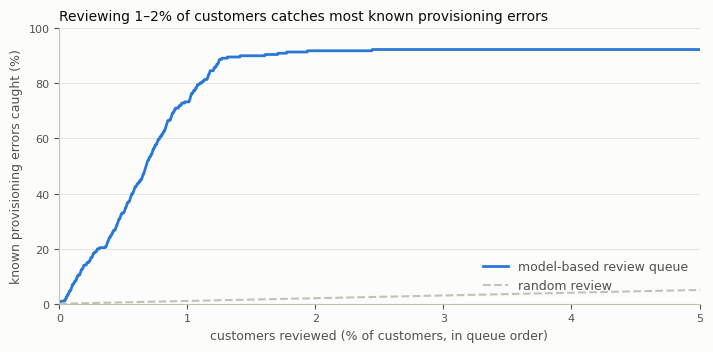

separately, 8.6% of validation customers have a CRM record that itself looks corrupted (impossible categories or bursts of rare products) -> a CRM data-quality queue


In [17]:
Y_obs = Y_raw[va][cl]                    # what the billing system actually contains
e = noisy[va][cl]                        # known provisioning errors
disagree = np.abs(P_val[cl] - Y_obs) > 0.5
flagged = disagree.any(1)
n_items = disagree.sum(1)
rare_cust = rare_tr[va][cl] > 0
key = (~flagged) * 1000 + rare_cust * 100 + n_items      # unflagged last; rare-product customers last; fewer items first
order = np.lexsort((np.arange(len(e)), key))
caught = np.cumsum(e[order]) / max(e.sum(), 1)
reviewed = np.arange(1, len(e) + 1) / len(e)
base = e.mean()
print(f'{len(e):,} customers with a clean-looking CRM record; known provisioning errors among them: '
      f'{e.sum()} ({base:.2%}); flagged by the rule: {flagged.mean():.1%}')
rows = []
for share in (0.005, 0.01, 0.02, flagged.mean()):
    k = int(share * len(e))
    hit = e[order[:k]].sum()
    rows.append({'review the top': f'{share:.1%} of customers', 'alerts per 10,000': round(share * 10_000),
                 'known errors caught': f'{hit / e.sum():.0%}', 'precision (lower bound)': f'{hit / k:.0%}',
                 'lift vs random review': f'{hit / k / base:.0f}x'})
display(pd.DataFrame(rows).set_index('review the top'))

fig, ax = plt.subplots(figsize=(7.2, 3.6))
ax.plot(reviewed * 100, caught * 100, color=BLUE, lw=2, label='model-based review queue')
ax.plot([0, 100], [0, 100], color=AXIS, lw=1.5, ls='--', label='random review')
ax.set_xlim(0, 5)
ax.set_ylim(0, 100)
style(ax, grid='y')
ax.set_xlabel('customers reviewed (% of customers, in queue order)', color=INK2)
ax.set_ylabel('known provisioning errors caught (%)', color=INK2)
ax.set_title('Reviewing 1–2% of customers catches most known provisioning errors', loc='left', color=INK, fontsize=10)
ax.legend(frameon=False, labelcolor=INK2, loc='lower right')
plt.tight_layout()
plt.show()

flag_corrupt = ~clean_like[va]
print(f'separately, {flag_corrupt.mean():.1%} of validation customers have a CRM record that itself looks corrupted '
      f'(impossible categories or bursts of rare products) -> a CRM data-quality queue')

### How reliable is the detector?

Two checks:
1. a confidence interval on the recall above;
2. **synthetic errors** — the known errors are only 1–2-item deviations in *repeated*
   configurations, so we also corrupt the actual billing of clean customers ourselves
   (1, 2 or 3 items; a missing billed item, or a plausible extra item drawn in proportion to
   how common it is) and check what the same queue catches. We report this separately for
   customers whose configuration is unique, which is every customer in the test set.

In [18]:
n_cl = len(e)
codes_cl, _ = pd.factorize(groups[va][cl])


def ratio_ci(num, den, b=2000, seed=0):
    sn, sd = np.bincount(codes_cl, weights=num), np.bincount(codes_cl, weights=den)
    idx = np.random.default_rng(seed).integers(0, len(sn), size=(b, len(sn)))
    return np.percentile(sn[idx].sum(1) / np.maximum(sd[idx].sum(1), 1), [2.5, 97.5])


top2 = np.zeros(n_cl, bool)
top2[order[:int(0.02 * n_cl)]] = True
lo, hi = ratio_ci((e & top2).astype(float), e.astype(float))
print(f'1) known errors caught in the top 2%: {(e & top2).sum() / e.sum():.0%} '
      f'(95% CI {lo:.0%}-{hi:.0%}, resampling configurations)')


def queue_order(D):
    dis = D > 0.5
    k_ = (~dis.any(1)) * 1000 + rare_cust * 100 + dis.sum(1)
    return np.lexsort((np.arange(len(D)), k_))


rng_s = np.random.default_rng(1)
D0 = np.abs(P_val[cl] - Y_obs)
clean_idx = np.flatnonzero(~e)
item_prev = Y[keep].mean(0)
cfg_size = pd.Series(codes_cl).map(pd.Series(codes_cl).value_counts()).to_numpy()
unique_cfg = cfg_size == 1
syn = []
for kind in ('missing item', 'extra item'):
    for k in (1, 2, 3):
        res_ = []
        for _ in range(3):
            S = rng_s.choice(clean_idx, size=int(0.0065 * n_cl), replace=False)
            Ymod = Y_obs[S].copy()
            for r_ in range(len(S)):
                pool = np.flatnonzero(Ymod[r_] == (1 if kind == 'missing item' else 0))
                pick = (rng_s.choice(pool, size=min(k, len(pool)), replace=False) if kind == 'missing item'
                        else rng_s.choice(pool, size=k, replace=False, p=item_prev[pool] / item_prev[pool].sum()))
                Ymod[r_, pick] = 1 - Ymod[r_, pick]
            Dm = D0.copy()
            Dm[S] = np.abs(P_val[cl][S] - Ymod)
            in_top = np.zeros(n_cl, bool)
            in_top[queue_order(Dm)[:int(0.02 * n_cl)]] = True
            res_.append((in_top[S].mean(), in_top[S][unique_cfg[S]].mean(), in_top[S][~unique_cfg[S]].mean()))
        a = np.mean(res_, 0)
        syn.append({'injected error': kind, 'items': k, 'caught in top 2%': f'{a[0]:.0%}',
                    'unique configuration': f'{a[1]:.0%}', 'repeated configuration': f'{a[2]:.0%}'})
print(f'2) synthetic errors injected into {int(0.0065 * n_cl)} clean customers (3 repetitions each); '
      f'{unique_cfg[clean_idx].mean():.0%} of clean customers here have a unique configuration:')
display(pd.DataFrame(syn).set_index(['injected error', 'items']))

1) known errors caught in the top 2%: 92% (95% CI 86%-96%, resampling configurations)


2) synthetic errors injected into 216 clean customers (3 repetitions each); 26% of clean customers here have a unique configuration:


caught in top 2% unique configuration repeated configuration
injected error items                                                             
missing item   1                  94%                  81%                    99%
               2                  92%                  81%                    97%
               3                  94%                  80%                    98%
extra item     1                  92%                  77%                    98%
               2                  94%                  80%                    98%
               3                  91%                  76%                    97%

**Reading the result.**
- **Known errors, honest split first.** On seed 7, the split the rule was *not* designed on,
  the top 1% of customers catches 59% of known errors and the top 2% catches **83%**
  (95% CI 73–92%; `scripts/sprint3/review_checks.py`). On seed 42 (shown above) it is 73% and
  92% [86–96%]. That is roughly 40× better than reviewing customers at random.
- **Synthetic errors.** Practically every injected error is flagged. Within a 2% review
  budget the queue catches about 92% of them, **whether the error is 1, 2 or 3 items** and
  whether an item is missing or extra, so it does not only work for small errors. The weak
  spot is customers with a **unique configuration** (every test customer): about 76–82% are
  caught, against 97–98% for repeated configurations, on both splits.
- **False alarms** come mainly from the model's own mistakes on unusual customers, which is
  why they are queued last. *Ranking by model confidence alone* fails for the same reason.

**How it would run in production.**
- **Two queues.**
  1. *Billing check* (above): nightly batch that compares predicted with actual billing, and
     sends the top-scored customers to an analyst. The review budget sets the cut-off.
  2. *CRM data-quality check*: records with impossible categories or bursts of rare products
     are flagged for correction. They are **not** deleted: dropping rows is a *training*
     decision only, and a real customer with several rare products is still scored.
- **Thresholds in production.** The "rare" threshold (0.2%) and cut-off (4 rare packs) are
  recomputed from the current CRM base. They need no knowledge of a test set.
- **Monitoring and retraining.** Track alert volume, confirmed-error rate and product
  frequency drift. Retrain monthly or when new products launch: a product never seen in
  training cannot be mapped and should be routed to manual review.
- **Coverage limit.** About 2% of customers have billing items the model cannot vouch for
  (see above); their alerts deserve lower priority or a dedicated rule.

---
# Explainability (SHAP)

SHAP values come from LightGBM's built-in TreeSHAP (`pred_contrib=True`, identical to
`shap.TreeExplainer`), in log-odds, on clean-like **validation** rows.
- **Importance** of a CRM column for a BIL column = mean |SHAP| over the rows where that BIL
  item is billed (true or predicted). This answers "why does this item get billed?".
- **Expected driver** = the CRM column that co-occurs best with the BIL column in the
  cleaned training data. It is computed without the model, so agreement is a real check.

In [19]:
Xf, Yf = Xu.astype(np.float32), Yu.astype(np.float32)
inter = Xf.T @ Yf
cooc = np.minimum(inter / np.maximum(Xf.sum(0)[:, None], 1), inter / np.maximum(Yf.sum(0)[None, :], 1))
expected, expected_score = cooc.argmax(0), cooc.max(0)

rng = np.random.default_rng(0)
Xv = X[va].astype(np.float32)
cl_idx = np.flatnonzero(cl)
imp = np.zeros((len(bil_cols), len(crm_cols)), np.float32)
pos_rows = {}
t0 = time.time()
for j, m in enumerate(models):
    rows = cl_idx[(Yv[cl_idx, j] == 1) | (pred_val[cl_idx, j] == 1)]
    if len(rows) > 400:
        rows = rng.choice(rows, 400, replace=False)
    if len(rows) == 0:
        rows = rng.choice(cl_idx, 400, replace=False)
    pos_rows[j] = Xv[rows]
    if not isinstance(m, float):
        imp[j] = np.abs(m.booster_.predict(pos_rows[j], pred_contrib=True)[:, :-1]).mean(0)
print(f'SHAP for 731 models in {time.time() - t0:.0f}s')

top = imp.argmax(1)
conc = imp.max(1) / np.maximum(imp.sum(1), 1e-12)
tp_, fp_, fn_ = (((yt == 1) & (yp == 1)).sum(0), ((yt == 0) & (yp == 1)).sum(0), ((yt == 1) & (yp == 0)).sum(0))
f1_col = np.where(tp_ + fp_ + fn_ > 0, 2 * tp_ / np.maximum(2 * tp_ + fp_ + fn_, 1), np.nan)
in_top3 = np.array([expected[j] in np.argsort(-imp[j])[:3] for j in range(len(bil_cols))])
strong = expected_score >= 0.8
display(pd.DataFrame([
    {'BIL columns': 'with a clear expected driver (score >= 0.8)', 'count': strong.sum(),
     'top SHAP driver = expected': (top == expected)[strong].mean(), 'expected in SHAP top 3': in_top3[strong].mean()},
    {'BIL columns': 'without one', 'count': (~strong).sum(),
     'top SHAP driver = expected': (top == expected)[~strong].mean(), 'expected in SHAP top 3': in_top3[~strong].mean()},
]).set_index('BIL columns').style.format({'top SHAP driver = expected': '{:.1%}', 'expected in SHAP top 3': '{:.1%}'}))

SHAP for 731 models in 6s


,count,top SHAP driver = expected,expected in SHAP top 3
BIL columns,,,
with a clear expected driver (score >= 0.8),233,95.7%,99.1%
without one,498,46.4%,50.2%


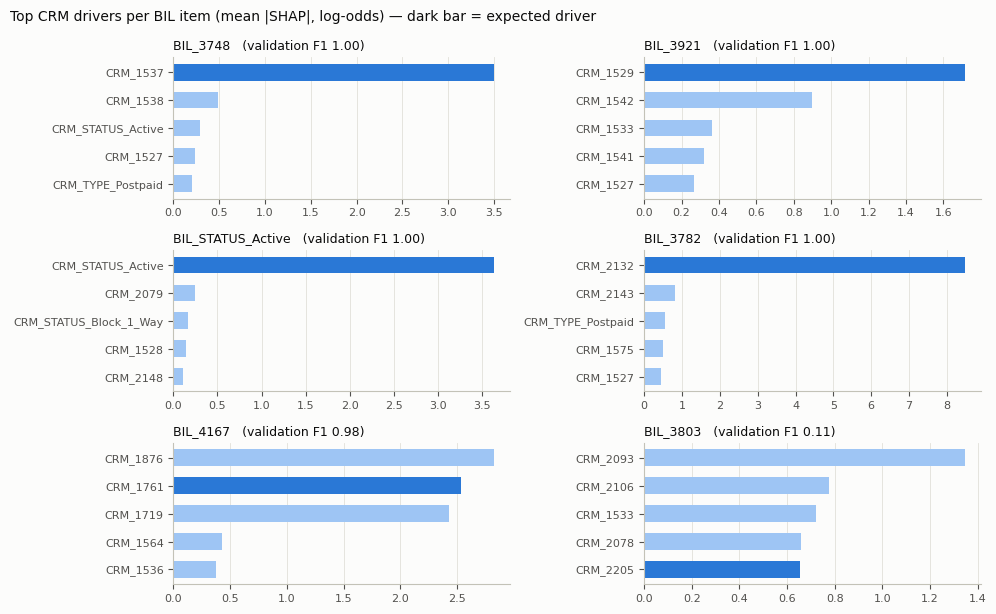

In [20]:
SELECTED = ['BIL_3748_PACK', 'BIL_3921_PACK', 'BIL_SUBSCRIBER_STATUS_ORIG_Active', 'BIL_3782_PACK',
            'BIL_4167_PACK', 'BIL_3803_PACK']
short = lambda c: c.replace('_PACK', '').replace('SUBSCRIBER_STATUS_ORIG_', 'STATUS_').replace('SUBSCRIBER_TYPE_ORIG_', 'TYPE_')
crm_arr = np.array(crm_cols)
fig, axes = plt.subplots(3, 2, figsize=(10, 6.2))
for ax, b in zip(axes.ravel(), SELECTED):
    j = bil_cols.index(b)
    order = np.argsort(-imp[j])[:5][::-1]
    ax.barh([short(crm_arr[f]) for f in order], imp[j, order],
            color=[BLUE if f == expected[j] else LIGHT_BLUE for f in order], height=0.6)
    style(ax)
    ax.set_title(f'{short(b)}   (validation F1 {f1_col[j]:.2f})', loc='left', color=INK, fontsize=9)
fig.suptitle('Top CRM drivers per BIL item (mean |SHAP|, log-odds) — dark bar = expected driver',
             x=0.01, ha='left', color=INK, fontsize=10)
plt.tight_layout()
plt.show()

**Where a clear CRM → BIL link exists, the model uses exactly that link** — on the 233 billing
items with a clear expected driver, the model's top driver matches it for ~96% of items and is
in its top 3 for ~99%. For the other 498 items there is no single dominant CRM cause (they are
billed for combinations of products, or flip between identical customers), so a single-driver
check does not apply and agreement is only ~46%. For example:
- `BIL_3748` ← `CRM_1537`;
- the BIL `Active` status ← the CRM `Active` status;
- the rare `BIL_3782` ← the rare `CRM_2132`.

`BIL_4167` is billed for any of three CRM packs (`1876`, `1761`, `1719`). That is the
many-to-one CRM → BIL mapping, and the model handles it. `BIL_3803` has no dominant cause,
and its F1 is low.

,columns,median_F1
band,,
≤ 0.3 (diffuse),299,0.00
0.3–0.5,116,0.67
0.5–0.7,148,0.95
> 0.7 (one clear driver),168,0.99


Spearman(concentration, F1) over 726 columns: +0.86


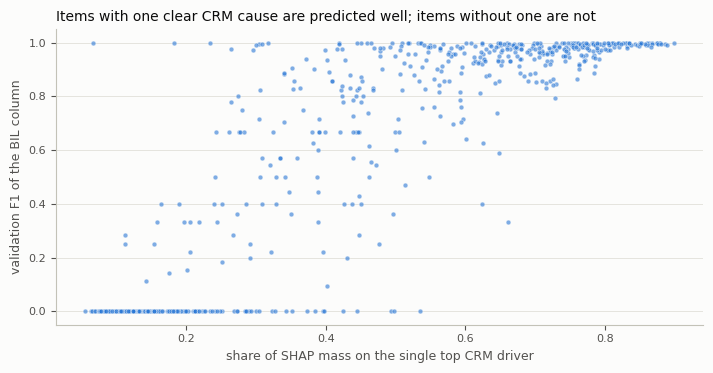

noise check: median SHAP share on rare CRM packs 1.1%; 119 columns lean > 50% on rare packs, and for 100% of them that rare pack is the column's own expected driver


In [21]:
ok = ~np.isnan(f1_col)
bands = pd.cut(conc, [0, 0.3, 0.5, 0.7, 1.0], labels=['≤ 0.3 (diffuse)', '0.3–0.5', '0.5–0.7', '> 0.7 (one clear driver)'])
summary = pd.DataFrame({'band': bands, 'f1': f1_col}).groupby('band', observed=True).agg(
    columns=('f1', 'size'), median_F1=('f1', 'median'))
display(summary.style.format({'median_F1': '{:.2f}'}))
print(f'Spearman(concentration, F1) over {ok.sum()} columns: {spearmanr(conc[ok], f1_col[ok]).statistic:+.2f}')

fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.scatter(conc[ok], f1_col[ok], s=12, color=BLUE, alpha=0.6, edgecolors=SURFACE, linewidths=0.5)
style(ax, grid='y')
ax.set_xlabel('share of SHAP mass on the single top CRM driver', color=INK2)
ax.set_ylabel('validation F1 of the BIL column', color=INK2)
ax.set_title('Items with one clear CRM cause are predicted well; items without one are not',
             loc='left', color=INK, fontsize=10)
plt.tight_layout()
plt.show()

share_rare = imp[:, rare_crm].sum(1) / np.maximum(imp.sum(1), 1e-12)
hi = share_rare > 0.5
print(f'noise check: median SHAP share on rare CRM packs {np.median(share_rare):.1%}; '
      f'{hi.sum()} columns lean > 50% on rare packs, and for {np.mean(rare_crm[expected[hi]]):.0%} of them '
      f'that rare pack is the column\'s own expected driver')

- **The errors have an explanation.** How much of a column's explanation rests on its single
  top driver strongly predicts its F1. Billing items with no single CRM cause (many of them
  differ even between customers with *identical* CRM data) are not predictable from CRM,
  which is the floor that Sprint 3's further experiments could not move.
- **No sign of learning the injected noise.** Columns that lean on rare CRM packs lean on
  *their own* rare product, never on unrelated rare packs.

### A worked example of an error

In [22]:
err_rows = np.flatnonzero(cl & ((pred_val != Yv).sum(1) == 1))
cands = [(i, int(np.flatnonzero(pred_val[i] != Yv[i])[0])) for i in err_rows]
# Prefer a missed item whose expected driver (a rare product) is present; else any missed item.
example = next(((i, j) for i, j in cands if Yv[i, j] == 1 and Xv[i, expected[j]] == 1 and rare_crm[expected[j]]),
               next((i, j) for i, j in cands if Yv[i, j] == 1))
i, j = example
contrib = models[j].booster_.predict(Xv[i:i + 1], pred_contrib=True)[0]
present = np.flatnonzero(Xv[i] == 1)
order = present[np.argsort(-np.abs(contrib[present]))][:5]
print(f'{bil_cols[j]} is billed for this customer, but the model predicted p = {P_val[i, j]:.2f} (< 0.5)')
print(f'baseline log-odds {contrib[-1]:+.2f}; largest contributions from the CRM columns the customer has:')
for f in order:
    print(f'   {crm_cols[f]:34s} {contrib[f]:+6.2f}' + ('   <- expected driver (rare product)' if f == expected[j] else ''))

BIL_4139_PACK is billed for this customer, but the model predicted p = 0.23 (< 0.5)
baseline log-odds -8.44; largest contributions from the CRM columns the customer has:
   CRM_1727_PACK                       +7.60   <- expected driver (rare product)
   CRM_1570_PACK                       +0.63
   CRM_1608_PACK                       +0.55
   CRM_1525_PACK                       -0.50
   CRM_1606_PACK                       -0.46


The model found the **right** cause: the rare CRM product pushes strongly towards billing the
item. But with only a handful of clean training examples, the regularised evidence stops just
short of 0.5. This is why the remaining errors are mostly missed items on rare products.

---
# Final fit and submission

The frozen model (Stage 1 + Stage 2) is re-fitted on all of `train.csv` (minus
suspected-corrupted rows) and applied to `test.csv`. The long-tail list is rebuilt from
`train.csv` alone (out-of-fold inside the training data).

In [23]:
keep_all = test_like & (rare_tr < 4)
Xa, Ya = unique_configs(X[keep_all], Y[keep_all])
t0 = time.time()
final_models = fit_models(Xa, Ya)
_, pred_test1 = predict(final_models, X_test)
print(f'Stage 1: dropped {(~keep_all).sum():,} rows ({(~keep_all).mean():.1%}); trained on {len(Xa):,} unique '
      f'configurations in {time.time() - t0:.0f}s')

t0 = time.time()
lt_all = long_tail_labels(Ya, oof_proba(Xa, Ya), config_weights(X[keep_all]))
final_spec = fit_specialists(Xa, Ya, lt_all)
pred_test = two_stage(pred_test1, final_spec, lt_all, X_test)
added = pred_test != pred_test1
print(f'Stage 2: {len(lt_all)} long-tail items (training OOF F1 < 0.5); {int(added.sum())} billing items added '
      f'for {int(added.any(1).sum())} test customers [{time.time() - t0:.0f}s]')

sub = pd.DataFrame({'MSISDN': msisdn_test, 'Bill_Conf': [''.join(r) for r in pred_test.astype(str)]})
assert len(sub) == 97_100 and sub.notna().all().all() and sub['MSISDN'].is_unique
assert sub['Bill_Conf'].str.len().eq(731).all() and sub['Bill_Conf'].str.fullmatch('[01]+').all()
os.makedirs(OUT, exist_ok=True)
sub.to_csv(f'{OUT}/submission_sprint3_final.csv', index=False)
print('written data/derived/submission_sprint3_final.csv:', sub.shape)
sub.head(3)

Stage 1: dropped 13,131 rows (7.0%); trained on 54,387 unique configurations in 164s


Stage 2: 332 long-tail items (training OOF F1 < 0.5); 787 billing items added for 655 test customers [539s]


written data/derived/submission_sprint3_final.csv: (97100, 2)


,MSISDN,Bill_Conf
0,db67b03cf9fb8ea96077cd34c7a28139,10000000000000000000000000000000000000000000000000000000000000000000000101100001010001...
1,2ac0d310d5cf1a96587af614d37b8b54,10000000001000000000000000000001000000000000000000000000000000000000000001100011000001...
2,a8f289fbd263794ac74059a18c1d10a5,11000001101111000000000000000000000100000000000000000000000000000000000000000000000000...


---
# Test against `solution.csv`

The model is frozen. Only now is `solution.csv` read, to score the submission against the
correct test billing. It was never used for training, features, settings or thresholds.

In [24]:
sol = pd.read_csv(f'{DATA}/solution.csv', dtype=str)
m = sub.merge(sol, on='MSISDN', suffixes=('', '_true'))
assert len(m) == len(sub) == len(sol) and (m['MSISDN'].to_numpy() == msisdn_test).all()
to_bits = lambda s: np.array([np.frombuffer(x.encode(), np.uint8) - 48 for x in s])
Yt_test, Yp_test = to_bits(m['Bill_Conf_true']), to_bits(m['Bill_Conf'])
wrong = (Yt_test != Yp_test).sum(1)
test_emr = np.mean(wrong == 0)
display(pd.Series({
    'test EMR': f'{test_emr:.2%}',
    'rows exactly right': f'{(wrong == 0).sum():,} of {len(wrong):,}',
    'rows 1 bit off': f'{np.mean(wrong == 1):.2%}',
    'rows 2+ bits off': f'{np.mean(wrong >= 2):.2%}',
    'bit accuracy': f'{(Yt_test == Yp_test).mean():.5%}',
    'F1 micro': f'{f1_score(Yt_test, Yp_test, average="micro"):.4f}',
}).to_frame('test (solution.csv)'))

# Every test row is its own CRM configuration, so a plain binomial interval is appropriate here.
print(f'distinct CRM configurations in test: {factorize_rows(X_test)[1]:,} of {len(X_test):,} rows')
half = 1.96 * np.sqrt(test_emr * (1 - test_emr) / len(wrong))
print(f'95% confidence interval: [{test_emr - half:.2%}, {test_emr + half:.2%}] (±{half * 100:.2f} pt)')
print(f'gap to the ~98% benchmark: {(0.98 - test_emr) * len(wrong):.0f} customers')
test_emr1 = np.mean((pred_test1 == Yt_test).all(1))
print(f'Stage 1 alone: test EMR {test_emr1:.2%} -> Stage 2 adds {(test_emr - test_emr1) * 100:+.2f} pt '
      f'({(test_emr - test_emr1) * len(wrong):+.0f} customers)')
act_t = Yt_test.sum(0) > 0
f1m = lambda Pr: f1_score(Yt_test[:, act_t], Pr[:, act_t], average='macro', zero_division=0)
print(f'test macro F1 (items with a positive): Stage 1 {f1m(pred_test1):.4f} -> final {f1m(Yp_test):.4f}')
be = (Yt_test != Yp_test).mean()
print(f'bit error rate {be:.2e}: EMR if errors were independent {(1 - be) ** 731:.2%} vs actual {test_emr:.2%}')

,test (solution.csv)
test EMR,97.51%
rows exactly right,"94,681 of 97,100"
rows 1 bit off,1.91%
rows 2+ bits off,0.58%
bit accuracy,99.99465%
F1 micro,0.9987


distinct CRM configurations in test: 97,100 of 97,100 rows
95% confidence interval: [97.41%, 97.61%] (±0.10 pt)
gap to the ~98% benchmark: 477 customers
Stage 1 alone: test EMR 97.21% -> Stage 2 adds +0.30 pt (+290 customers)


test macro F1 (items with a positive): Stage 1 0.7013 -> final 0.7693
bit error rate 5.35e-05: EMR if errors were independent 96.17% vs actual 97.51%


### Ablation: is the corruption filter really worth it? (recomputed live)

Stage 1 trained on all of `train.csv` **without** dropping the suspected-corrupted rows,
compared with Stage 1 trained with the filter (Stage 2 left out on both sides, so only the
filter differs).

Stage 1 without the filter: test EMR 94.67% | with the filter: 97.21% | difference +2.54 pt (+2467 customers) [206s]


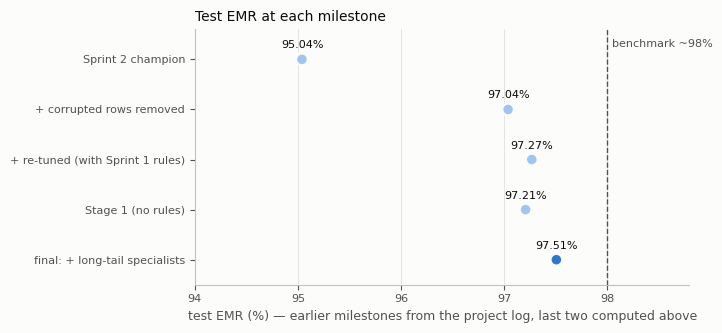

In [25]:
Xn, Yn = unique_configs(X, Y)
t0 = time.time()
_, pred_nofilter = predict(fit_models(Xn, Yn), X_test)
truth = sol.set_index('MSISDN').loc[msisdn_test, 'Bill_Conf'].to_numpy()
emr_nofilter = np.mean(np.array([''.join(r) for r in pred_nofilter.astype(str)]) == truth)
print(f'Stage 1 without the filter: test EMR {emr_nofilter:.2%} | with the filter: {test_emr1:.2%} | '
      f'difference {(test_emr1 - emr_nofilter) * 100:+.2f} pt ({(test_emr1 - emr_nofilter) * len(wrong):+.0f} customers) '
      f'[{time.time() - t0:.0f}s]')

milestones = {'Sprint 2 champion': 0.9504, '+ corrupted rows removed': 0.9704,
              '+ re-tuned (with Sprint 1 rules)': 0.9727, 'Stage 1 (no rules)': test_emr1,
              'final: + long-tail specialists': test_emr}
labels = list(milestones)[::-1]
vals = [milestones[k] * 100 for k in labels]
fig, ax = plt.subplots(figsize=(7.2, 3.4))
# Dots, not bars: the axis is zoomed to 94-99%, and bars would exaggerate the differences.
ax.scatter(vals, labels, s=70, color=[BLUE] + [LIGHT_BLUE] * 4, edgecolors=SURFACE, linewidths=1.5, zorder=3)
ax.axvline(98, color=INK2, lw=1, ls='--')
ax.text(98.05, 4.25, 'benchmark ~98%', color=INK2, fontsize=8)
for y, v in enumerate(vals):
    ax.text(v, y + 0.22, f'{v:.2f}%', ha='center', color=INK, fontsize=8)
ax.set_xlim(94, 98.8)
ax.set_ylim(-0.5, 4.6)
style(ax)
ax.set_xlabel('test EMR (%) — earlier milestones from the project log, last two computed above', color=INK2)
ax.set_title('Test EMR at each milestone', loc='left', color=INK, fontsize=10)
plt.tight_layout()
plt.show()

---
# Threats to validity

| Risk | Status |
|---|---|
| The 42 Sprint 1 additive rules were mined from all of `train.csv` (including later validation rows). | Removed from the final model. Their gain is real but tiny (+0.02, ~6 customers). |
| Sprint 1 SVD and χ² selection were fit on all of `train.csv`. | Not used by the final model (raw columns only). |
| The clean-like metric and the corruption filter were designed by comparing train and test *inputs*. | Feature-only (no labels); disclosed. Key decisions are also checked with paired tests, on all validation rows (5-fold) and on test. |
| Validation rows of one configuration are not independent. | Uncertainty is computed by resampling configurations (SE ~0.35–0.38 pt, not ~0.1); decisions use paired tests. |
| Does the grouped split mirror test? | Only partly. The nearest training configuration is 1 product away for 70% of validation rows vs 53% of test rows, so validation is *easier* on neighbour distance; it is *harder* on unusual customers (more far-away rows). The biases partly cancel, so validation is used to rank choices and the test set (CI ±0.10) to measure the result. |
| Rows removed → survival bias? | Removed from **training** only; the test score uses all 97,100 test rows. |
| `solution.csv` scored at several milestones. | Always after selection; never used to choose. A diagnostic, not an untouched holdout. |
| Earlier experiment results (Sprints 2–3 tables) are reported, not recomputed here. | They come from the project's scripts and leaderboard; the final model and the filter ablation are re-fitted live. |
| No multi-output neural net or ensemble of classifier chains. | Not tried: the regularised chain tied plain per-label models (Sprint 2), so label dependencies were not where the errors were. |
| Stage 2's rare-product gate was chosen after seeing which customers broke on seed 42. | Seed 7 and all 5 folds confirm it (both metrics up in every fold); the gate uses CRM inputs only. |
| Stage 2 was selected among several structural variants (cascade, communities, rules, chain). | All variants were compared on the same baseline with paired tests on two splits; the chosen one is the simplest that won, and it held in 5-fold. |
| Error-detection precision. | Measured only against provisioning errors that can be confirmed (repeated configurations): a lower bound. |

# Conclusions

1. **Sprint 1:** the data is extremely sparse and noisy, and test configurations are new.
   Validation is therefore grouped by configuration and scored against consensus targets.
2. **Sprint 2:** billing is close to additive per CRM pack — a tuned linear model gets within
   0.15–0.23 points — and one LightGBM per BIL column, on raw columns, trained on unique
   configurations without weights, adds the rest. Sprint 1's PCA/SVD and column collapsing hurt.
3. **Sprint 3:** an audit revealed ~7–8% of training rows that look corrupted by random
   injection (impossible categories, bursts of random rare products). Removing them from
   training and re-tuning regularisation took test EMR from **95.04% to 97.21%**
   (95% CI ±0.10). Both decisions are confirmed by paired tests on two splits and by the live
   ablation.
4. **Stage 2, the long tail:** about 330 billing items are almost never predicted (macro F1
   ~0.52). A third of them follow CRM product *combinations* that transfer to new customers;
   most of the rest look like residue of the random injection. Class-weighted specialists that
   may only add items, and only for customers with a rare product, raise both metrics on both
   splits and in all 5 folds (5-fold: EMR 96.83% → 96.99%, macro F1 0.524 → 0.539). On test:
   **97.21% → 97.51%** (95% CI ±0.10), +290 customers; test macro F1 0.70 → 0.77. Threshold
   tuning, label communities, stacked probabilities, rule overrides and targeted chains were
   tried and rejected. The final model needs only `train.csv` and `test.csv`.
5. **Business use:** flagging customers whose actual billing disagrees with the model, and
   queueing unusual customers last, turns it into a provisioning-error detector: reviewing
   2% of customers catches 83% (honest split; 92% on the design split) of known errors,
   about 40× better than random review. On synthetic 1–3-item errors it catches ~92%, but
   only ~80% for customers with a unique configuration — the realistic production case.
6. **Explainability:** on the 233 billing items with a clear CRM cause the model relies on
   that cause (~96% top-1 agreement with an independent check). Its errors are on items with
   no clear CRM cause, and it does not exploit the injected noise.
7. **Remaining gap to ~98%:** about 480 customers, mostly with 1–2 rare products: items whose
   positives look like injected noise, and real rare-product links with too little evidence.